# Домашня робота 3 — Self-Distillation зі стиснутими моделями (VGG11 / CIFAR-10)

**Курс:** Efficient ML, SET University

Ідея knowledge distillation (KD): маленька/стиснута модель («учень») вчиться не лише
на жорстких мітках, а й на **м'яких ймовірностях великої моделі-«вчителя»** — тих
самих «майже правильних» відтінках (кіт трохи схожий на собаку й зовсім не на
вантажівку), яких у one-hot мітках немає. Тут це **self-distillation**: вчитель — наша
ж непорушена fp32 VGG11 з ДЗ1/ДЗ2 (90.71% на тесті), а учень — та сама
архітектура, але **стиснута** інструментами ДЗ1 (прунінг) і ДЗ2 (квантизація).

**Функція втрат** (Hinton, 2015):

$$L = \alpha\,\mathrm{CE}(\text{student}, y) \;+\; (1-\alpha)\,T^2\,
\mathrm{KL}\!\left(\text{softmax}(\tfrac{z_t}{T}) \,\big\|\,
\text{softmax}(\tfrac{z_s}{T})\right)$$

Температура $T>1$ «розм'якшує» обидва розподіли, множник $T^2$ повертає масштаб
градієнта м'якої частини (він інакше падає як $1/T^2$), а $\alpha$ балансує жорстку і
м'яку складові: $\alpha=1$ — чистий CE (наш baseline відновлення), $\alpha=0$ — чиста
дистиляція.

**Головне порівняння — чесна пара KD vs CE.** Для кожного стиснутого учня ми
до-навчаємо його **двічі з однакового стиснутого старту**, з ідентичними
оптимізатором, розкладом LR, кількістю епох і seed. Одна гілка — звичайне відновлення
на CE (чесний baseline), друга додає м'які таргети вчителя. Тож будь-яка різниця в
точності — заслуга саме дистиляції.

### Підсумок (тест — раз на модель, T=4, α=0.5)

| Стиснутий учень | Стиснення | Розмір, МБ | CE-only (тест) | KD (тест) | KD − CE |
|---|---|---|---|---|---|
| Вчитель fp32 (з ДЗ1) | 1× | 37.98 | — | 90.71% | — |
| pruned 80% | 4.3× | 8.81 | 90.73% | **90.76%** | +0.03 п.п. |
| 2-bit quant | 15.8× | 2.41 | 88.20% | **88.35%** | +0.15 п.п. |
| prune80%+4-bit | 17.5× | 2.17 | 90.65% | **90.83%** | +0.18 п.п. |

Виграш дистиляції **скромний**; у цьому запуску простежується **тенденція** — що
сильніше стиснення, то більший виграш: від +0.03 п.п.
на найлегшому учні (4.3×) до +0.18 п.п. на
найагресивнішому (prune80%+4-bit, 17.5×). Числа — single-seed (тест
раз на модель), тож це тенденція, а не строгий закон. Там, де CE-only і сам майже
дотягується до вчителя (прунінг), м'яким таргетам нема куди тягнути; що більше точності
з'їдає стиснення — то більше простору для KD. Найкраща точка сумарно —
prune80%+4-bit: 90.83% при 17.5× стисненні.

## 1. Підготовка

In [1]:
import json, inspect
import torch
import matplotlib.pyplot as plt

from src.utils import set_seed, get_device
from src.data import build_loaders
from src.model import build_vgg11_cifar, count_parameters
from src import distill, prune, kmeans_quant, qat, plots

RESULTS = "results"
set_seed(42)
device = get_device()
print("device:", device, "| torch:", torch.__version__)

device: cuda | torch: 2.11.0+cu130


## 2. Дані та вчитель

CIFAR-10, той самий поділ, що й у ДЗ1/ДЗ2: 45 000 train / 5 000 val / 10 000 test.
Валідація — для всіх проміжних рішень (криві відновлення, ablation), тест — рівно один
раз на фінальну модель. **Вчитель** — щільна VGG11 з ДЗ1 (fp32, 90.71%
на тесті, 37.98 МБ), заморожена (`eval()`, без градієнтів).

In [2]:
train_loader, val_loader, test_loader = build_loaders("./data", batch_size=256)
print(f"train={len(train_loader.dataset)}  val={len(val_loader.dataset)}  test={len(test_loader.dataset)}")

teacher = build_vgg11_cifar().to(device)
teacher.load_state_dict(torch.load("../hw1/results/baseline.pt", map_location=device))
teacher.eval()
for p in teacher.parameters():
    p.requires_grad_(False)
print(f"вчитель: {count_parameters(teacher)/1e6:.2f}M параметрів")

/home/deploy/efficientml/venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


train=45000  val=5000  test=10000


вчитель: 9.49M параметрів


## 3. KD-loss: жорсткі + м'які мітки

Ось уся дистиляційна логіка. `alpha=1` вимикає KL-складову й повертає чистий
`CrossEntropyLoss` — тому і KD-, і CE-only-прогони йдуть **одним кодом**, різниця лише
в `alpha`. Множник `T²` тримає градієнт м'якої частини на тому самому масштабі, що й
CE, тож один learning rate працює за будь-якої температури.

In [3]:
print(inspect.getsource(distill.DistillLoss))

class DistillLoss(nn.Module):
    """Combined hard-label + soft-label distillation loss.

    forward(student_logits, teacher_logits, targets) -> scalar loss.

    When alpha == 1 the KL term is skipped entirely, so this same object also
    expresses the pure cross-entropy recovery baseline (teacher_logits may be
    None in that case). That lets the KD run and the CE-only run share one code
    path -- the only thing that changes is alpha -- which is what makes the
    KD-vs-CE comparison a fair one.
    """

    def __init__(self, temperature: float = 4.0, alpha: float = 0.5):
        super().__init__()
        self.T = float(temperature)
        self.alpha = float(alpha)
        self.ce = nn.CrossEntropyLoss()

    def forward(self, student_logits, teacher_logits, targets):
        ce = self.ce(student_logits, targets)
        if self.alpha >= 1.0 or teacher_logits is None:
            return ce
        T = self.T
        # Standard KD direction: KL(teacher || student) at temperatu

Швидка перевірка властивостей (те саме, що в `tests/test_distill.py`): при `alpha=1`
KD-loss дорівнює крос-ентропії, а якщо учень уже збігається з учителем — чиста
KD-складова (`alpha=0`) прямує до нуля.

In [4]:
import torch.nn.functional as F
s = torch.randn(16, 10, requires_grad=True); t = torch.randn(16, 10)
y = torch.randint(0, 10, (16,))
print("alpha=1 == CE:", torch.allclose(distill.DistillLoss(alpha=1.0)(s, t, y), F.cross_entropy(s, y)))
z = torch.randn(16, 10)
print("matched logits -> ~0 KD:", distill.DistillLoss(alpha=0.0)(z.clone().requires_grad_(True), z.clone(), y).item())

alpha=1 == CE: True
matched logits -> ~0 KD: 1.7881393432617188e-07


## 4. Головний експеримент — KD vs CE для трьох стиснутих учнів

Три режими стиснення (все — та сама VGG11):

- **pruned 80%** — unstructured magnitude pruning з
  ДЗ1; маски накладаються після кожного кроку, відновлення SGD+cosine.
- **2-bit quant** — найважчий випадок (лише 4 значення
  ваги на шар); відновлення — centroid-QAT з ДЗ2 під KD-лоссом замість CE.
- **prune80%+4-bit** — учень «Deep Compression»:
  спершу прунінг, потім квантизація ненульових ваг, відновлення centroid-QAT + KD.

Для кожного — дві гілки з однакового старту й seed: CE-only і KD. Дивимось на різницю.

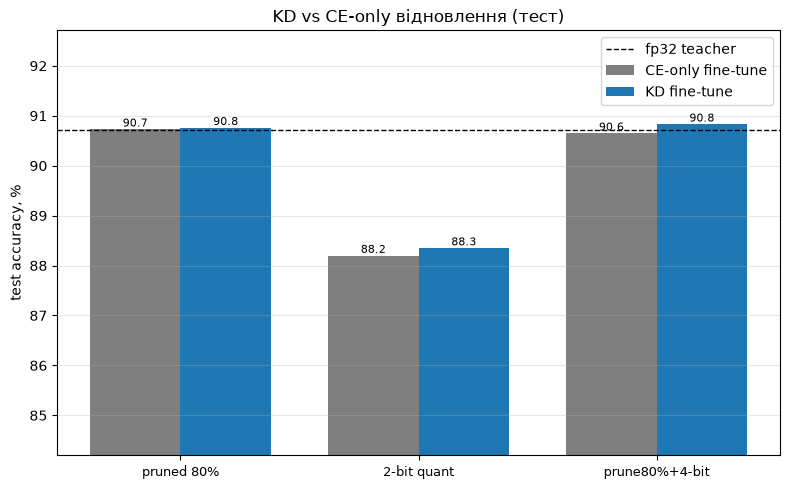

TEST (раз на модель):
  pruned 80%      : init val 63.28%  |  CE 90.73%  KD 90.76%  (+0.03 pp)  @ 8.81MB (4.3x)
  2-bit quant     : init val 40.30%  |  CE 88.20%  KD 88.35%  (+0.15 pp)  @ 2.41MB (15.8x)
  prune80%+4-bit  : init val 62.54%  |  CE 90.65%  KD 90.83%  (+0.18 pp)  @ 2.17MB (17.5x)


In [5]:
dist = json.load(open(f"{RESULTS}/distill.json"))
order = [r for r in ["pruned", "quant2", "prune_quant"] if r in dist]
tags = [dist[r]["tag"] for r in order]
ce_t = [dist[r]["ce"]["test"] for r in order]
kd_t = [dist[r]["kd"]["test"] for r in order]
plots.plot_kd_comparison(tags, ce_t, kd_t, baseline_acc=dist["teacher"]["test"],
                         title="KD vs CE-only відновлення (тест)")
plt.show()
print("TEST (раз на модель):")
for r in order:
    x = dist[r]
    print(f"  {x['tag']:<16}: init val {x['pre_finetune_val']*100:5.2f}%  |  "
          f"CE {x['ce']['test']*100:5.2f}%  KD {x['kd']['test']*100:5.2f}%  "
          f"({(x['kd']['test']-x['ce']['test'])*100:+.2f} pp)  @ {x['size_MB']:.2f}MB ({x['compression_x']:.1f}x)")

Криві відновлення на найважчому учні (2-bit quant): PTQ-старт валиться до
40.30% на val, а до-навчання центроїдів під учителя піднімає його назад.

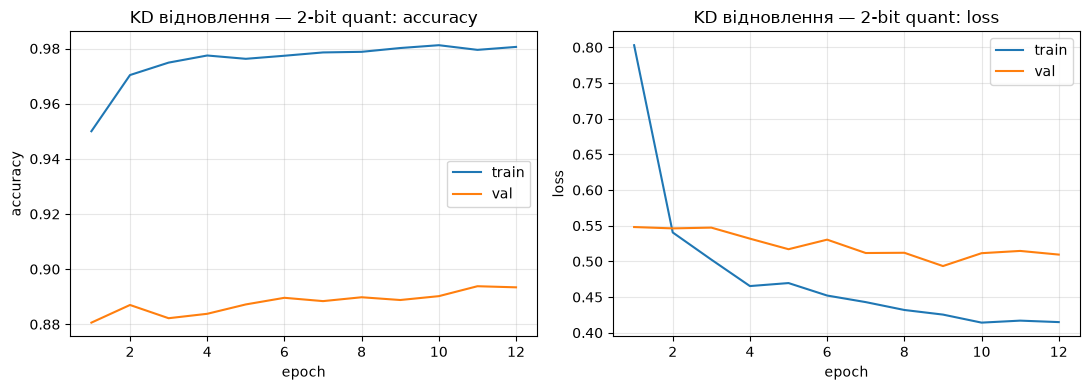

In [6]:
hist = dist["quant2"]["kd"]["history"]
plots.plot_history(hist, "KD відновлення — 2-bit quant")
plt.show()

**Що видно.** KD і CE обидва добре відновлюють точність, а виграш дистиляції у цьому
запуску **тим більший, чим сильніше стиснення** (тенденція single-seed, у порядку
зростання стиснення):

- pruned 80% (4.3×): +0.03 п.п. на тесті —
  80%-розріджена модель зберігає fp32-точність ненульових ваг, тож CE й сам майже
  дотягується до вчителя, і м'яким таргетам мало що додати.
- 2-bit quant (15.8×): +0.15 п.п. — лише 4 значення ваги
  на шар, розрив після стиснення великий, і «темні знання» вчителя вже помітно допомагають.
- prune80%+4-bit (17.5×): +0.18 п.п. — найсильніше стиснення дає й найбільший виграш KD; поєднання прунінгу і квантизації — найкраща точка сумарно (90.83%).

Величина виграшу невелика (десяті частки п.п.) — це чесний результат, а не помилка:
причини розбираємо у звіті нижче (учитель сам лише 90.71%, self-distillation
з однаковою архітектурою має обмежену «стелю»).

## 5. Ablation — дві ручки KD (учень 2-bit, val)

Свіпи робимо на **2-бітному** учні (найбільший розрив → найбільше простору для KD) і
**лише на валідації** — це підбір гіперпараметрів, торкатися тесту тут не можна.

- **Температура T** (α=0.5 фіксовано): скільки «пом'якшувати» розподіл
  вчителя.
- **α** (T=4 фіксовано): баланс CE ↔ м'які мітки; α=1 — чистий CE
  (референсна лінія).

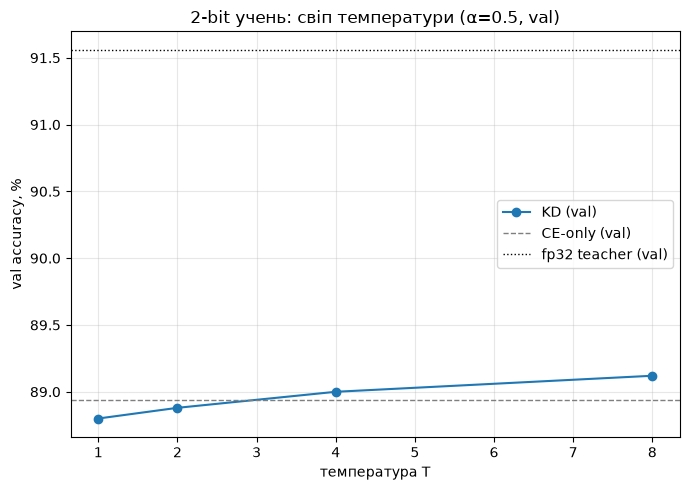

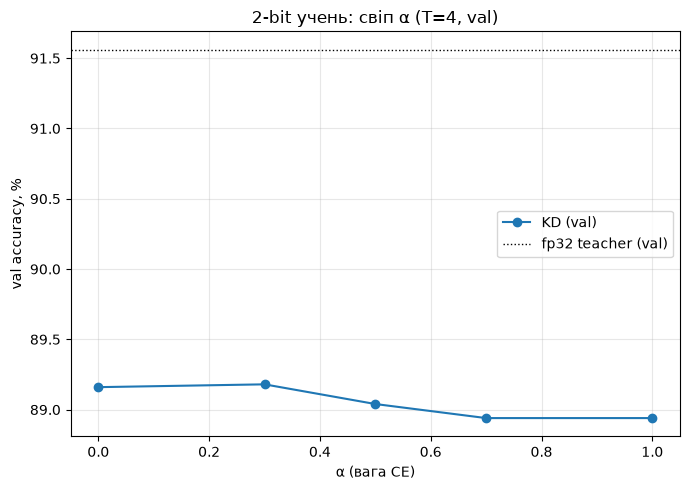

  T=1: val 88.80%
  T=2: val 88.88%
  T=4: val 89.00%
  T=8: val 89.12%
  alpha=0.0: val 89.16%
  alpha=0.3: val 89.18%
  alpha=0.5: val 89.04%
  alpha=0.7: val 88.94%
  alpha=1.0: val 88.94%


In [7]:
abl = json.load(open(f"{RESULTS}/kd_ablation.json"))
tp = abl["temperature_sweep"]; ap = abl["alpha_sweep"]
plots.plot_kd_ablation([t for t, _ in tp], [v for _, v in tp],
                       xlabel="температура T", baseline_val=abl["teacher_val"],
                       ce_val=abl.get("ce_only_val"),
                       title=f"2-bit учень: свіп температури (α={abl['fixed_alpha']}, val)")
plt.show()
plots.plot_kd_ablation([a for a, _ in ap], [v for _, v in ap],
                       xlabel="α (вага CE)", baseline_val=abl["teacher_val"],
                       title=f"2-bit учень: свіп α (T={abl['fixed_temp']:.0f}, val)")
plt.show()
for T, v in tp: print(f"  T={T}: val {v*100:.2f}%")
for a, v in ap: print(f"  alpha={a}: val {v*100:.2f}%")

**Що видно.** По **температурі** — у нашому діапазоні вища T стабільно краща: від
88.80% при T=1 до 89.12% при T=8
(монотонно). М'якший розподіл вчителя несе більше «темних знань», і 2-бітному учневі це
корисно; ще вищі T варто було б перевірити окремо. По **α** найкраще — 0.3
(89.18% val), і взагалі вага в бік дистиляції допомагає: чиста дистиляція (α=0, 89.16%) випереджає чистий CE (α=1, 88.94%), а невелика домішка CE (α≈0.3) — трохи краща за обидві крайнощі.
Тобто саме м'які таргети — корисний сигнал тут; жорсткі мітки радше страхують.
(Головний прогін використав T=4, α=0.5 — розумний дефолт; свіп
показує, що T=8/α=0.3 витиснули б ще трохи.)

## 6. Бонус — NetAug (Network Augmentation) + KD

**Ідея.** На відміну від великих мереж, **маленькі моделі недонавчаються**, а не
переднавчаються — тож звична регуляризація (dropout, аугментація даних) їм радше
шкодить. NetAug робить навпаки: під час навчання **розширює ємність** мережі. Цільова
маленька модель — це під-мережа ширшої *augmented*-мережі зі **спільними вагами**; на
кожному кроці forward'имо і базу, і розширений варіант, а лоси сумуємо. Розширений
forward проштовхує додатковий градієнт крізь спільні ваги. На inference лишається
**тільки база**. Джерело: Cai et al., «Network Augmentation for Tiny Deep Learning»,
ICLR 2022 ([arXiv:2110.08890](https://arxiv.org/abs/2110.08890)).

**Наш сетап.** Ціль — **width-compressed VGG11 (0.25× канали)**,
0.58M параметрів (у 16× менше за вчителя) — справді мала
модель, той режим, де NetAug має сенс. Це четверта вісь стиснення (по ширині) на додачу
до прунінгу/кванту з ядра. Augmentation — до повної ширини (×4), що
відповідає паперу (помірний фактор). **Інтеграція з KD:** і база, і augmented-гілка
вчаться під м'які таргети того самого вчителя (`netaug_train` бере `DistillLoss`).
Конфіг: T=4, α=0.5, λ_aug=1,
base=0.25×, aug=1.0×, 40 epochs,
seed=42.

**Чесне порівняння 2×2** — усе з того самого init/seed, 40 епох, однаковий
оптимізатор; різниця лише в методі:

|  | CE-лос | KD-лос |
|---|---|---|
| **звичайне навчання** | 85.42% | **86.39%** |
| **NetAug** | 85.71% | 86.27% |

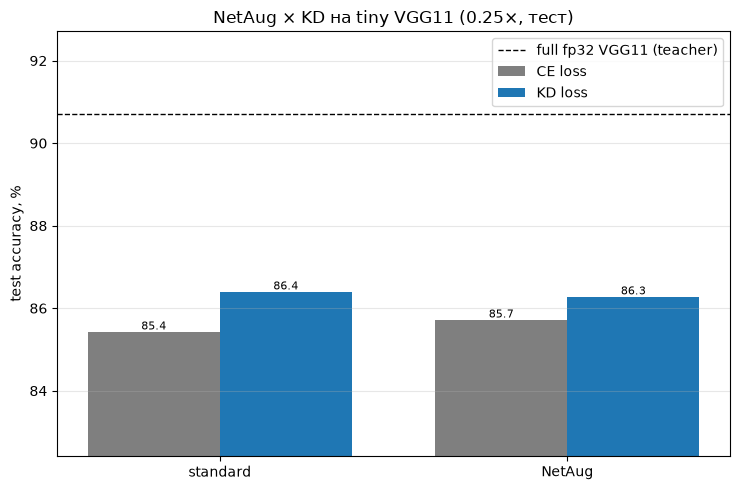

tiny 0.25x VGG11 (0.58M), тест:
  ce         : 85.42%
  kd         : 86.39%
  netaug_ce  : 85.71%
  netaug_kd  : 86.27%
KD +0.97 | NetAug +0.29 | NetAug+KD +0.85 п.п. (vs CE)


In [8]:
na = json.load(open(f"{RESULTS}/netaug.json"))
cells = {k: na[k]["test"] for k in ["ce", "kd", "netaug_ce", "netaug_kd"]}
plots.plot_netaug_2x2(cells, teacher_acc=na["teacher_test"], full_acc=na["teacher_test"],
                      title=f"NetAug × KD на tiny VGG11 ({na['base_mult']}×, тест)")
plt.show()
print(f"tiny {na['base_mult']}x VGG11 ({na['base_params']/1e6:.2f}M), тест:")
for k in ["ce", "kd", "netaug_ce", "netaug_kd"]:
    print(f"  {k:<11}: {na[k]['test']*100:.2f}%")
print(f"KD {(na['kd']['test']-na['ce']['test'])*100:+.2f} | "
      f"NetAug {(na['netaug_ce']['test']-na['ce']['test'])*100:+.2f} | "
      f"NetAug+KD {(na['netaug_kd']['test']-na['ce']['test'])*100:+.2f} п.п. (vs CE)")

**Що видно (проти чистого CE).** KD помітно допомагає (+0.97 п.п.), NetAug трохи допомагає
(+0.29 п.п.), разом NetAug+KD — +0.85 п.п. над CE. Найкращий кут — **KD**
(86.39%). У нашому **одному запуску** NetAug не покращив KD (поверх KD -0.12 п.п.), але за одного seed це цілком може бути шумом — для статистичного висновку потрібні 3–5 seed і mean±std. Правдоподібна гіпотеза: KD і NetAug дають той самий тип додаткового сигналу недонавченій моделі, тож коли вже є сильний вчитель, augmented-гілка докидає мало.
Обидві техніки — про **навчання**, не про розмір: на inference база однакова
(0.58M) незалежно від методу.

## 7. Як ми це робили: підходи та спроби

**Стартова точка.** Нічого не перенавчали з нуля: вчитель — готова fp32-VGG11 з ДЗ1,
стиснення — код прунінгу (ДЗ1) і квантизації/QAT (ДЗ2). Зверху дописали лише
дистиляцію (`src/distill.py`).

**Один код для чесного порівняння.** Щоб KD-vs-CE було чесним, зробили так, що
`alpha=1` у KD-лоссі точно дорівнює крос-ентропії — тоді CE-гілка й KD-гілка йдуть
**одним циклом** з тими самими оптимізатором/розкладом/сідом, і різниця лишається
тільки в лоссі. Для квант-учня це той самий centroid-QAT із ДЗ2, у який ми додали
опційного вчителя (одна гілка `if teacher is not None`).

**Технічна пастка з градієнтами.** Логіти вчителя рахуємо під `torch.no_grad()`, а не
`inference_mode`: inference-тензори не можна підмішувати в autograd-граф учня (вони
йдуть як константний таргет у KL). Через це спершу ловили помилку — і саме тому в коді
стоїть `no_grad`, а не `inference_mode`.

**Чого очікували й що вийшло.** Гіпотеза була проста: KD найкорисніший там, де
стиснення найсильніше. Дані її підтвердили — на 2 бітах виграш +0.15 п.п.,
а на прунінгу майже нуль. Це не «KD не працює», а «на прунінгу CE вже й так відновлює
модель до вчителя, стелі майже нема».

## 8. Звіт: висновки і рефлексія

**Що спрацювало добре.** KD-пайплайн (CE + T²·KL) стабільно й без зусиль інтегрувався і
з прунінгом, і з centroid-QAT. Виграш дистиляції у цьому запуску тим більший, чим сильніше
стиснення (тенденція single-seed): найбільший на найагресивнішому учні
(prune80%+4-bit, 17.5×,
+0.18 п.п. на тесті), і саме він — найкраща точка сумарно
(90.83%). Self-distillation працює навіть за однакової архітектури
вчителя й учня. Ablation: вища температура (T=8 найкраща у нашому діапазоні)
і перевага дистиляції в суміші (α=0.3; чистий CE α=1 — найгірший) — корисний
сигнал тут саме м'які таргети.

**Що вийшло не так, як очікувалось.** Виграш скромний — десяті частки п.п. На прунінг-учні
він майже нульовий (+0.03 п.п.) — 80%-розріджена
модель зберігає fp32-точність ненульових ваг і відновлюється майже до вчителя і без KD,
тож дистиляції нема куди тягнути. Ефект KD впирається не в саму дистиляцію, а в те,
**скільки точності реально втрачено при стисненні** — там, де втрата мала, малий і виграш.

**Чому результати можуть бути не ідеальними.** (1) Вчитель — сам лише 90.71%,
тобто «стеля» дистиляції невисока; сильніший учитель (ширша мережа чи ансамбль) дав би
кращі м'які таргети. (2) Self-distillation з однаковою архітектурою обмежене: учень не
«слабший клас» моделей, а та сама мережа зі стисненими вагами, тож простір для
перенесення знань вужчий. (3) Гіперпараметри (T, α) підбирали на 2-бітному учні й
перенесли на решту — оптимум для кожного режиму міг би трохи відрізнятися. (4) Бюджет
епох невеликий; довше до-навчання трохи підняло б обидві гілки.

**Як покращити.** Сильніший/ширший учитель або ансамбль; feature-based дистиляція (не
лише логіти, а й проміжні активації — FitNets/attention transfer); підбір (T, α) під
кожен режим окремо; поєднати з бонусом **NetAug** (тренувати стиснуту мережу, тимчасово
розширюючи її ємність), щоб дати учневі більше «простору» під час навчання; для
Raspberry Pi з фінального проекту — дистиляція одночасно зі quantization-aware
експортом у INT8.

## 9. Відтворення

```bash
python run_distill.py     --baseline ../hw1/results/baseline.pt --data-dir ./data --out results
python run_kd_ablation.py --baseline ../hw1/results/baseline.pt --data-dir ./data --out results
python run_netaug.py      --baseline ../hw1/results/baseline.pt --data-dir ./data --out results   # бонус
python build_notebook.py results
python -m pytest tests/          # KD-loss + NetAug elastic-VGG weight sharing
```

Код у `src/`: `distill.py` (KD-loss + KD-цикл навчання), `qat.py` (centroid-QAT з ДЗ2,
розширений опційним учителем), `netaug.py` (elastic-VGG11 + NetAug-цикл, бонус);
`model/data/engine/prune/kmeans_quant/plots/utils` — реюз із ДЗ1/ДЗ2. Версії пакетів —
у `requirements.txt`.